# **Movie Recommendation System**

### Code written by: Vinayak Ramachandra Bhosale  & Daniel Cisneros

## **Exploratory Data Analysis**

In [ ]:
# Libraries

# Data Analysis 
import pandas as pd
import numpy as np
import re
import scipy.stats as st

# Visualization 
import seaborn as sns 
import matplotlib.pyplot as plt
%matplotlib inline

#### Data Extraction

In [ ]:
movies = pd.read_csv('/content/movies.csv')
ratings = pd.read_csv('/content/ratings.csv')

#### **Exploring Data**

In [ ]:
movies

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
...,...,...,...
62418,209157,We (2018),Drama
62419,209159,Window of the Soul (2001),Documentary
62420,209163,Bad Poems (2018),Comedy|Drama
62421,209169,A Girl Thing (2001),(no genres listed)


In [ ]:
ratings

,userId,movieId,rating,timestamp
0,1,296,5.0,1147880044
1,1,306,3.5,1147868817
2,1,307,5.0,1147868828
3,1,665,5.0,1147878820
4,1,899,3.5,1147868510
...,...,...,...,...
25000090,162541,50872,4.5,1240953372
25000091,162541,55768,2.5,1240951998
25000092,162541,56176,2.0,1240950697
25000093,162541,58559,4.0,1240953434


**Data types of data**

In [ ]:
movies.dtypes

movieId     int64
title      object
genres     object
dtype: object

In [ ]:
ratings.dtypes

userId         int64
movieId        int64
rating       float64
timestamp      int64
dtype: object

**Extracting Numerical and Categorical Features**

In [ ]:
# Numerical Features for Movies

movie_num_features = movies.select_dtypes(include = [np.number])
movie_num_features.columns

Index(['movieId'], dtype='object')

In [ ]:
# Numerical Features for Ratings

rating_num_features = ratings.select_dtypes(include = [np.number])
rating_num_features.columns

Index(['userId', 'movieId', 'rating', 'timestamp'], dtype='object')

In [ ]:
# Categorical Features for Movies

movie_cat_features = movies.select_dtypes(include= [object])
movie_cat_features.columns

Index(['title', 'genres'], dtype='object')

In [ ]:
# Categorical Features for Ratings

rating_cat_features = ratings.select_dtypes(include= [object])
rating_cat_features.columns

Index([], dtype='object')

**Missing Values Percentage**

In [ ]:
# Movies

movie_percentage = movies.isnull().mean()*100
movie_percentage = movie_percentage.to_frame("nulls")
movie_percentage.sort_values("nulls", inplace = True, ascending = False)
movie_percentage

,nulls
movieId,0.0
title,0.0
genres,0.0


In [ ]:
# Ratings

rating_percentage = ratings.isnull().mean()*100
rating_percentage = rating_percentage.to_frame("nulls")
rating_percentage.sort_values("nulls", inplace = True, ascending = False)
rating_percentage

,nulls
userId,0.0
movieId,0.0
rating,0.0
timestamp,0.0


In [ ]:
print(movie_cat_features["genres"].value_counts())

Drama                                   9056
Comedy                                  5674
(no genres listed)                      5062
Documentary                             4731
Comedy|Drama                            2386
                                        ... 
Action|Adventure|Crime|Fantasy             1
Drama|Film-Noir|Musical|Thriller           1
Action|Drama|Horror|Mystery                1
Adventure|Comedy|Sci-Fi|Thriller|War       1
Comedy|Horror|Mystery|Sci-Fi|Western       1
Name: genres, Length: 1639, dtype: int64


In [ ]:
print(movie_cat_features["title"].value_counts())

The Void (2016)                                2
Seven Years Bad Luck (1921)                    2
Clear History (2013)                           2
Enron: The Smartest Guys in the Room (2005)    2
Deranged (2012)                                2
                                              ..
$ellebrity (Sellebrity) (2012)                 1
Macabre (Macabro) (1980)                       1
Punk's Dead: SLC Punk! 2 (2014)                1
Chinese Hercules (1973)                        1
Women of Devil's Island (1962)                 1
Name: title, Length: 62325, dtype: int64


**Cleaning Titles of Movies**

In [ ]:
# Function for Cleaning Titles of Movies

def cleaning_titles(titles):
    
    titles = re.sub("[^a-zA-Z0-9 ]", "", titles)
    return titles

In [ ]:
movies["clean_titles"] = movies["title"].apply(cleaning_titles)

In [ ]:
movies

,movieId,title,genres,clean_titles
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,Toy Story 1995
1,2,Jumanji (1995),Adventure|Children|Fantasy,Jumanji 1995
2,3,Grumpier Old Men (1995),Comedy|Romance,Grumpier Old Men 1995
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,Waiting to Exhale 1995
4,5,Father of the Bride Part II (1995),Comedy,Father of the Bride Part II 1995
...,...,...,...,...
62418,209157,We (2018),Drama,We 2018
62419,209159,Window of the Soul (2001),Documentary,Window of the Soul 2001
62420,209163,Bad Poems (2018),Comedy|Drama,Bad Poems 2018
62421,209169,A Girl Thing (2001),(no genres listed),A Girl Thing 2001


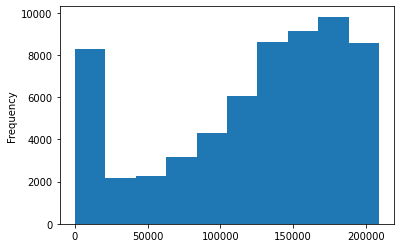

<ipython-input-18-6c97ee752001>:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y, kde= False, fit=st.johnsonsu)
<ipython-input-18-6c97ee752001>:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y, kde= False, fit=st.norm)
<ipython-input-18-6c97ee752001>:11: UserWarning: 

`distplot` is a deprec

count     62423.000000
mean     122220.387646
std       63264.744844
min           1.000000
25%       82146.500000
50%      138022.000000
75%      173222.000000
max      209171.000000
Name: movieId, dtype: float64

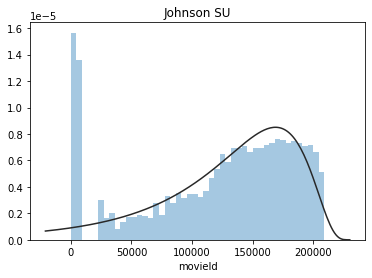

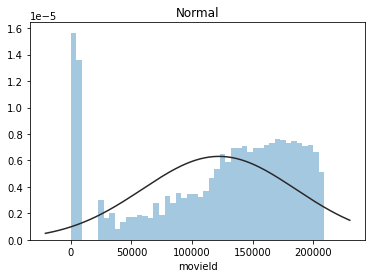

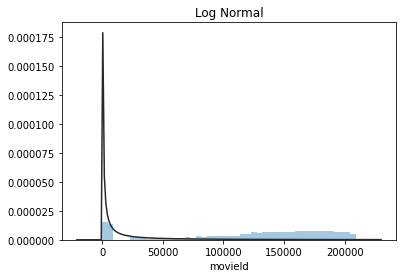

<Figure size 432x288 with 0 Axes>

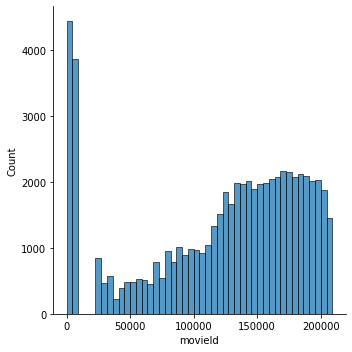

In [ ]:
movies["movieId"].astype(int).plot.hist()
plt.show()
y = movies["movieId"]
plt.figure(1); plt.title("Johnson SU")
sns.distplot(y, kde= False, fit=st.johnsonsu)

plt.figure(2); plt.title("Normal")
sns.distplot(y, kde= False, fit=st.norm)

plt.figure(3); plt.title("Log Normal")
sns.distplot(y, kde= False, fit=st.lognorm)

plt.figure(4)
sns.displot(y)
y.describe()

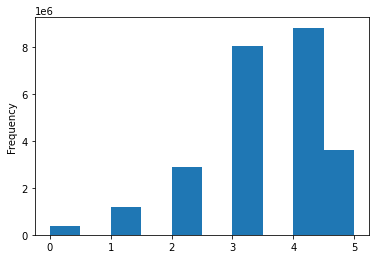

<ipython-input-19-49e2d60031a5>:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y2, kde= False)


count    2.500010e+07
mean     3.533854e+00
std      1.060744e+00
min      5.000000e-01
25%      3.000000e+00
50%      3.500000e+00
75%      4.000000e+00
max      5.000000e+00
Name: rating, dtype: float64

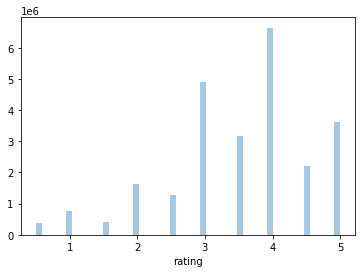

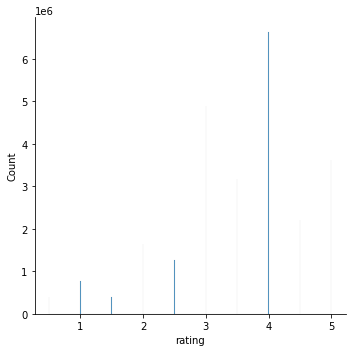

In [ ]:
ratings["rating"].astype(int).plot.hist()
plt.show()
y2 = ratings["rating"]
plt.figure(1); 
sns.distplot(y2, kde= False)

sns.displot(y2)
y2.describe()

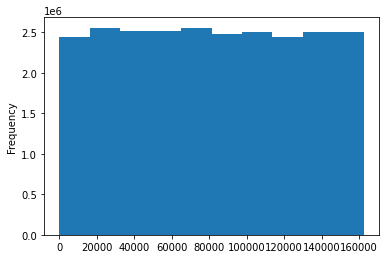

<ipython-input-20-bebba9d5ee38>:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y3, kde= False)


count    2.500010e+07
mean     8.118928e+04
std      4.679172e+04
min      1.000000e+00
25%      4.051000e+04
50%      8.091400e+04
75%      1.215570e+05
max      1.625410e+05
Name: userId, dtype: float64

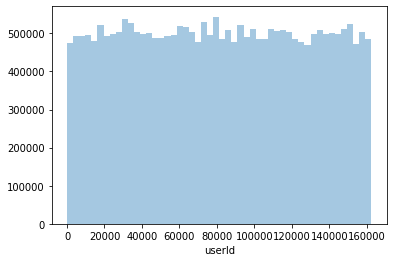

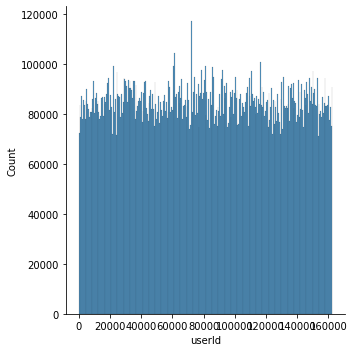

In [ ]:
ratings["userId"].astype(int).plot.hist()
plt.show()

y3 = ratings["userId"]
plt.figure(1); 
sns.distplot(y3, kde= False)



sns.displot(y3)
y3.describe()

<Axes: >

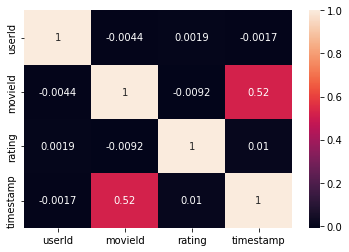

In [ ]:
rate_correlation = rating_num_features.corr()
sns.heatmap(rate_correlation, annot = True)

<Axes: >

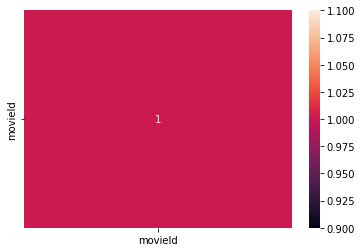

In [ ]:
mov_correlation = movie_num_features.corr()
sns.heatmap(mov_correlation, annot = True)

In [ ]:
movies

,movieId,title,genres,clean_titles
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,Toy Story 1995
1,2,Jumanji (1995),Adventure|Children|Fantasy,Jumanji 1995
2,3,Grumpier Old Men (1995),Comedy|Romance,Grumpier Old Men 1995
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,Waiting to Exhale 1995
4,5,Father of the Bride Part II (1995),Comedy,Father of the Bride Part II 1995
...,...,...,...,...
62418,209157,We (2018),Drama,We 2018
62419,209159,Window of the Soul (2001),Documentary,Window of the Soul 2001
62420,209163,Bad Poems (2018),Comedy|Drama,Bad Poems 2018
62421,209169,A Girl Thing (2001),(no genres listed),A Girl Thing 2001


In [ ]:
books = pd.read_csv('/content/books.csv')

In [ ]:
books

,Title,Author,Genre,Height,Publisher
0,Fundamentals of Wavelets,"Goswami, Jaideva",signal_processing,228,Wiley
1,Data Smart,"Foreman, John",data_science,235,Wiley
2,God Created the Integers,"Hawking, Stephen",mathematics,197,Penguin
3,Superfreakonomics,"Dubner, Stephen",economics,179,HarperCollins
4,Orientalism,"Said, Edward",history,197,Penguin
...,...,...,...,...,...
206,Structure and Randomness,"Tao, Terence",mathematics,252,NaN
207,Image Processing with MATLAB,"Eddins, Steve",signal_processing,241,NaN
208,Animal Farm,"Orwell, George",fiction,180,NaN
209,"Idiot, The","Dostoevsky, Fyodor",fiction,197,NaN


In [ ]:
print("Lenght of books:", len(books))
print("\n",books.dtypes)

Lenght of books: 211

 movieId          int64
title           object
genres          object
clean_titles    object
dtype: object


In [ ]:
# checking for max number of id for movies 

max(movies["movieId"])

209171

In [ ]:
booksid = [i for i in range(209172,209383)]

211

In [ ]:
# Adding a column of book id
books["bookid"] = booksid

In [ ]:
books = books[["bookid","Title","Genre"]]

In [ ]:
books["clean_titles"] = books["Title"].apply(cleaning_titles)

<ipython-input-31-74c31c0db1ac>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  books["clean_titles"] = books["Title"].apply(cleaning_titles)


In [ ]:
books

,bookid,Title,Genre,clean_titles
0,209172,Fundamentals of Wavelets,signal_processing,Fundamentals of Wavelets
1,209173,Data Smart,data_science,Data Smart
2,209174,God Created the Integers,mathematics,God Created the Integers
3,209175,Superfreakonomics,economics,Superfreakonomics
4,209176,Orientalism,history,Orientalism
...,...,...,...,...
206,209378,Structure and Randomness,mathematics,Structure and Randomness
207,209379,Image Processing with MATLAB,signal_processing,Image Processing with MATLAB
208,209380,Animal Farm,fiction,Animal Farm
209,209381,"Idiot, The",fiction,Idiot The


In [ ]:
# Numerical Features
books_num_features = books.select_dtypes(include = [np.number])
books_num_features.columns

Index(['movieId'], dtype='object')

In [ ]:
# Categorical Features
books_cat_features = books.select_dtypes(include= [object])
books_cat_features.columns

Index(['title', 'genres', 'clean_titles'], dtype='object')

In [ ]:
books_percentage = books.isnull().mean()*100
books_percentage = books_percentage.to_frame("nulls") 
books_percentage.sort_values("nulls", inplace = True, ascending = False)
books_percentage

,nulls
movieId,0.0
title,0.0
genres,0.0
clean_titles,0.0


In [ ]:
print(books_cat_features["genres"].value_counts())

fiction              64
nonfiction           30
history              26
data_science         17
philosophy           17
science              14
comic                13
computer_science     11
economics            10
mathematics           5
signal_processing     3
psychology            1
Name: genres, dtype: int64


In [ ]:
print(books_cat_features["title"].value_counts())

Angels & Demons                          2
Fundamentals of Wavelets                 1
Superman Earth One - 1                   1
Pattern Classification                   1
From Beirut to Jerusalem                 1
                                        ..
Last Mughal, The                         1
Social Choice & Welfare, Vol 39 No. 1    1
Radiowaril Bhashane & Shrutika           1
Gun Gayin Awadi                          1
Christmas Carol, A                       1
Name: title, Length: 210, dtype: int64


In [ ]:
books.columns = movies.columns
movies = movies.append(books, ignore_index=True)

<ipython-input-33-32c6e7ca43a7>:2: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  movies = movies.append(books, ignore_index=True)


In [ ]:
movies

,movieId,title,genres,clean_titles
11773,54621,Molière (2007),Comedy|Drama|Romance,Molire 2007
22530,115357,"Chair, The (2007)",Drama|Horror|Thriller,Chair The 2007
32976,142132,Saturday Island (1952),Adventure|Romance|War,Saturday Island 1952
40273,159048,One Way Out (2002),Action|Crime|Drama|Thriller,One Way Out 2002
20152,104379,Chennai Express (2013),Action|Adventure|Comedy,Chennai Express 2013
...,...,...,...,...
19367,100574,Raid on Rommel (1971),War,Raid on Rommel 1971
14457,75985,Repo Men (2010),Action|Sci-Fi|Thriller,Repo Men 2010
59163,200244,Καζαντζάκης (2017),(no genres listed),2017
46903,173407,Living (2012),(no genres listed),Living 2012


In [ ]:
movies = movies.sample(frac = 1)

In [ ]:
movies

,movieId,title,genres,clean_titles
11773,54621,Molière (2007),Comedy|Drama|Romance,Molire 2007
22530,115357,"Chair, The (2007)",Drama|Horror|Thriller,Chair The 2007
32976,142132,Saturday Island (1952),Adventure|Romance|War,Saturday Island 1952
40273,159048,One Way Out (2002),Action|Crime|Drama|Thriller,One Way Out 2002
20152,104379,Chennai Express (2013),Action|Adventure|Comedy,Chennai Express 2013
...,...,...,...,...
19367,100574,Raid on Rommel (1971),War,Raid on Rommel 1971
14457,75985,Repo Men (2010),Action|Sci-Fi|Thriller,Repo Men 2010
59163,200244,Καζαντζάκης (2017),(no genres listed),2017
46903,173407,Living (2012),(no genres listed),Living 2012


# Inverse document frequency

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(ngram_range=(1,2))

tfidf = vectorizer.fit_transform(movies["clean_titles"])

# Implementing Search Function

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def search_engine(title):
    title = cleaning_titles(title)
    query_vec = vectorizer.transform([title])
    similarity = cosine_similarity(query_vec, tfidf).flatten()
    indices = np.argpartition(similarity, -5)[-5:]
    results = movies.iloc[indices].iloc[::-1]
    return results

In [ ]:
import ipywidgets as widgets
from IPython.display import display

movie_input = widgets.Text(
    value='The Hulk',
    description='Movie/Book Title:',
    disabled=False
)
movie_list = widgets.Output()

def when_typed(data):
    with movie_list:
        movie_list.clear_output()
        title = data["new"]
        if len(title) > 4:
            display(search_engine(title))

movie_input.observe(when_typed, names='value')
display(movie_input, movie_list)

Text(value='The Hulk', description='Movie/Book Title:')

Output()

# Implementing the recommender system model

In [ ]:
def recommender_model(movie_id, already_watched=[]):
    similar_users = ratings[(ratings["movieId"] == movie_id) & (ratings["rating"] > 4)]["userId"].unique()
    similar_user_recs = ratings[(ratings["userId"].isin(similar_users)) & (ratings["rating"] > 4)]["movieId"]
    similar_user_recs = similar_user_recs.value_counts() / len(similar_users)

    similar_user_recs = similar_user_recs[similar_user_recs > .10]
    all_users = ratings[(ratings["movieId"].isin(similar_user_recs.index)) & (ratings["rating"] > 4)]
    all_user_recs = all_users["movieId"].value_counts() / len(all_users["userId"].unique())
    rec_percentages = pd.concat([similar_user_recs, all_user_recs], axis=1)
    rec_percentages.columns = ["similar", "all"]
    
    rec_percentages["score"] = rec_percentages["similar"] / rec_percentages["all"]
    rec_percentages = rec_percentages.sort_values("score", ascending=False)
    return rec_percentages.head(10).merge(movies, left_index=True, right_on="movieId")[["score", "title", "genres"]]

# Improved (Check point 2)

In [ ]:
def recommender_model(movie_id, already_watched=[]):
    similar_users = ratings[(ratings["movieId"] == movie_id) & (ratings["rating"] > 4)]["userId"].unique()
    similar_user_recs = ratings[(ratings["userId"].isin(similar_users)) & (ratings["rating"] > 4)]["movieId"]
    similar_user_recs = similar_user_recs.value_counts() / len(similar_users)

    similar_user_recs = similar_user_recs[similar_user_recs > .10]
    all_users = ratings[(ratings["movieId"].isin(similar_user_recs.index)) & (ratings["rating"] > 4)]
    all_user_recs = all_users["movieId"].value_counts() / len(all_users["userId"].unique())
    rec_percentages = pd.concat([similar_user_recs, all_user_recs], axis=1)
    rec_percentages.columns = ["similar", "all"]
    
    rec_percentages["score"] = rec_percentages["similar"] / rec_percentages["all"]
    rec_percentages = rec_percentages.sort_values("score", ascending=False)
    rec_df = rec_percentages.head(10).merge(movies, left_index=True, right_on="movieId")[["score", "title", "genres"]]
    rec_df["Watched/Read"] = rec_df["title"].isin(already_watched)
    return rec_df

In [ ]:
movie_name_input = widgets.Text(
    value='Toy Story',
    description='Movie/Book Title:',
    disabled=False
)
recommendation_list = widgets.Output()

def on_type(data):
    with recommendation_list:
        recommendation_list.clear_output()
        title = data["new"]
        if len(title) > 4:
            results = search_engine(title)
            movie_id = results.iloc[0]["movieId"]
            display(recommender_model(movie_id,["Toy Story 3 (2010)",
                                               "How to Train Your Dragon (2010)"]))

movie_name_input.observe(on_type, names='value')

display(movie_name_input, recommendation_list)

Text(value='Toy Story', description='Movie/Book Title:')

Output()